# Pacific Strata — exploración de datos para la historia

Este cuaderno busca **ganchos narrativos** en `web/data/dataset.json`:
22 países + 3 subregiones, 13 indicadores, 2003–2026.

| § | Pregunta |
|---|---|
| 1 | Cobertura y control de calidad — *qué NO se puede afirmar* |
| 2 | Herramientas estadísticas |
| 3 | Mínimos y máximos. ¿Qué tocó techo en la última medición? |
| 4 | ¿Cuánto hace que no se veía un valor así? |
| 5 | ¿Estable, subiendo o bajando? ¿El último punto fue atípico? |
| 6 | Ficha por serie — el explorador |
| 7 | Años sincronizados: récords simultáneos |
| 8 | Choque y recuperación (el desplome del turismo) |
| 9 | ¿Se abre o se cierra la brecha entre países? |
| 10 | Qué indicadores se mueven juntos |
| 11 | Qué país se sale del grupo |
| 12 | Ganchos narrativos, ordenados por fuerza |
| 13 | Qué contaría yo |

## Tres reglas que este cuaderno respeta

Las tres salen de mirar estos datos concretos, y saltárselas produce
afirmaciones falsas:

1. **«La última medición» no es 2026.** Cada serie termina en un año distinto
   (2019 a 2026). Siempre se usa el último valor *no nulo* de cada serie y se
   reporta de qué año es. Comparar un récord de 2019 con uno de 2025 sin
   decirlo sería engañoso.
2. **Los porcentajes no valen para las anomalías.** `temp_anomaly`,
   `surface_temp_anomaly`, `sea_level` y `rainfall_anomaly` miden desviaciones
   respecto de una línea base: el cero es convencional, no una ausencia. Un
   cambio «del −83 %» entre 0.6 °C y 0.1 °C no significa nada. Todo cálculo
   relativo excluye estos indicadores.
3. **Un récord en una serie corta no es noticia.** Con 5 puntos, que el último
   sea el máximo ocurre por azar 1 de cada 5 veces. Se exige un mínimo de
   observaciones y siempre se muestra `n`.

In [1]:
import json, math, itertools, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.width', 170, 'display.max_columns', 40,
              'display.float_format', lambda v: f'{v:,.3f}')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9,
                     'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})

# el cuaderno funciona igual desde analysis/ o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'web' / 'data' / 'dataset.json').exists())
D = json.loads((RAIZ / 'web' / 'data' / 'dataset.json').read_text(encoding='utf-8'))

YEARS = np.array(D['meta']['years'])
META = {i['id']: i for i in D['meta']['indicators']}
NOMBRE = {k: v['name'] for k, v in META.items()}
UNIDAD = {k: v['unit'] for k, v in META.items()}
DIVERGENTE = {k for k, v in META.items() if v['diverging']}   # anomalías
SUBREGIONES = {'Melanesia', 'Polynesia', 'Micronesia'}

print(RAIZ)
print(f'años        {YEARS[0]}-{YEARS[-1]}  ({len(YEARS)})')
print(f'unidades    {len(D["values"])}  '
      f'({len(D["values"]) - len(SUBREGIONES)} países + {len(SUBREGIONES)} subregiones)')
print(f'indicadores {len(META)}  ·  de anomalía: {", ".join(sorted(DIVERGENTE))}')
print(f'agregación  {D["meta"]["aggregation"]}  ·  sintético: {D["meta"]["synthetic"]}')

C:\Users\amado.esquer\Documents\Pacific Viz\Pacific-Viz-2026
años        2003-2026  (24)
unidades    25  (22 países + 3 subregiones)
indicadores 13  ·  de anomalía: rainfall_anomaly, sea_level, surface_temp_anomaly, temp_anomaly
agregación  media simple de países  ·  sintético: False


In [2]:
# --------------------------------------------------------------- tabla larga
# Una fila por (unidad, indicador, año): es el formato con el que groupby y
# pivot trabajan sin tener que reindexar a cada paso.
df = pd.DataFrame(
    [(u, i, int(y), np.nan if v is None else float(v))
     for u, series in D['values'].items()
     for i, vals in series.items()
     for y, v in zip(YEARS, vals)],
    columns=['unidad', 'indicador', 'anio', 'valor'])
df['es_subregion'] = df.unidad.isin(SUBREGIONES)

# PAIS = solo países. Las subregiones son medias de sus propios países:
# mezclarlas en un ranking sería contar dos veces los mismos datos.
PAIS = df[~df.es_subregion].dropna(subset=['valor']).copy()

print(f'{len(df):,} celdas · {df.valor.notna().sum():,} con dato '
      f'({df.valor.isna().mean():.1%} vacías)')
df.head()

7,800 celdas · 5,778 con dato (25.9% vacías)


,unidad,indicador,anio,valor,es_subregion
0,FJ,temp_anomaly,2003,0.200,False
1,FJ,temp_anomaly,2004,0.200,False
2,FJ,temp_anomaly,2005,0.300,False
3,FJ,temp_anomaly,2006,0.200,False
4,FJ,temp_anomaly,2007,0.400,False


---
## 1. Cobertura y control de calidad

Antes de buscar historias hay que saber qué aguantan los datos. Esta sección
existe para **restar** afirmaciones, no para sumarlas.

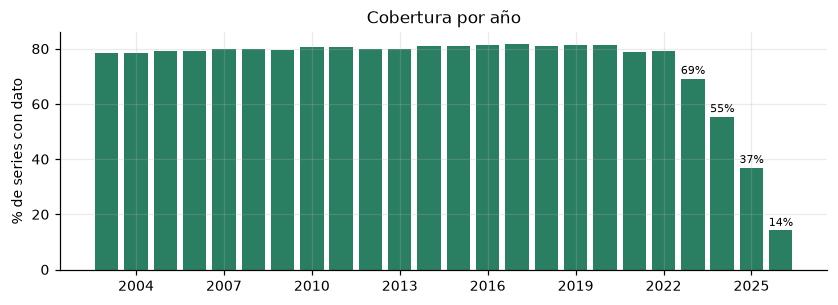

La cobertura se desploma al final: los últimos años están casi vacíos.
Por eso NUNCA se usa "2026" como "la última medición".

      con_dato  cobertura
anio                     
2021       256      0.788
2022       257      0.791
2023       225      0.692
2024       180      0.554
2025       120      0.369
2026        46      0.142


In [3]:
cob = (df.assign(hay=df.valor.notna())
         .pivot_table(index='anio', values='hay', aggfunc=['sum', 'mean']))
cob.columns = ['con_dato', 'cobertura']

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.bar(cob.index, cob.cobertura * 100, color='#2a7f62')
ax.set(ylabel='% de series con dato', title='Cobertura por año')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
for y in (2023, 2024, 2025, 2026):
    ax.annotate(f'{cob.cobertura[y]:.0%}', (y, cob.cobertura[y] * 100),
                textcoords='offset points', xytext=(0, 3), ha='center', fontsize=7)
plt.show()

print('La cobertura se desploma al final: los últimos años están casi vacíos.')
print('Por eso NUNCA se usa "2026" como "la última medición".')
print()
print(cob.tail(6).to_string())

In [4]:
# --------------------------- ¿en qué año termina de verdad cada serie?
fin = PAIS.groupby(['indicador', 'unidad']).anio.max().rename('fin').reset_index()
tf = fin.pivot_table(index='indicador', values='fin',
                     aggfunc=['min', 'max', 'median']).astype(int)
tf.columns = ['fin_mas_temprano', 'fin_mas_tardio', 'fin_tipico']
tf['nombre'] = tf.index.map(NOMBRE)
print('Año en que termina la serie, por indicador:')
print()
print(tf.sort_values('fin_tipico')[['nombre', 'fin_mas_temprano',
                                    'fin_mas_tardio', 'fin_tipico']].to_string())
print()
print('Los indicadores NO son comparables "al día de hoy": el turismo se corta')
print('en 2022-2024 y las anomalías de temperatura llegan a 2025.')

Año en que termina la serie, por indicador:

                                            nombre  fin_mas_temprano  fin_mas_tardio  fin_tipico
indicador                                                                                       
env_taxes                    Impuestos ambientales              2008            2020        2020
calci                                 Índice CALCI              2022            2022        2022
tourism                        Llegada de turistas              2017            2024        2022
power_gen                    Generación de energía              2023            2023        2023
sea_level                 Nivel del mar (anomalía)              2023            2023        2023
ghg_emissions             Emisiones GEI por cápita              2024            2024        2024
livestock_yield               Rendimiento ganadero              2024            2024        2024
crop_yield                    Rendimiento agrícola              2024            20

In [5]:
# --------------------------- series planas: una tendencia aquí no significa nada
alertas = []
for (u, i), g in PAIS.groupby(['unidad', 'indicador']):
    v = g.sort_values('anio').valor.values
    if len(v) < 4:
        continue
    distintos = len(np.unique(v))
    if np.ptp(v) == 0:
        alertas.append((u, NOMBRE[i], len(v), 'CONSTANTE', f'siempre {v[0]:g}'))
    elif distintos <= 3:
        alertas.append((u, NOMBRE[i], len(v), 'casi constante',
                        f'solo {distintos} valores distintos'))
A = pd.DataFrame(alertas, columns=['unidad', 'indicador', 'n', 'tipo', 'detalle'])
print(f'{len(A)} series planas o casi planas:')
print()
print(A.to_string(index=False) if len(A) else '  ninguna')

58 series planas o casi planas:

unidad                indicador  n           tipo                  detalle
    AS             Índice CALCI 20 casi constante solo 2 valores distintos
    AS Emisiones GEI por cápita 22      CONSTANTE              siempre 0.2
    AS Nivel del mar (anomalía) 21 casi constante solo 2 valores distintos
    CK        Red meteorológica 24 casi constante solo 2 valores distintos
    CK Nivel del mar (anomalía) 21 casi constante solo 2 valores distintos
    FJ        Red meteorológica 24 casi constante solo 3 valores distintos
    FJ Nivel del mar (anomalía) 21 casi constante solo 3 valores distintos
    FM             Índice CALCI 20 casi constante solo 3 valores distintos
    FM Emisiones GEI por cápita 22 casi constante solo 2 valores distintos
    FM        Red meteorológica 24      CONSTANTE                siempre 3
    GU Emisiones GEI por cápita 22      CONSTANTE              siempre 0.1
    KI             Índice CALCI 20      CONSTANTE              siem

In [6]:
# --------------------------- granularidad: ¿cuántos valores distintos hay?
# Un indicador redondeado a 0.1 no puede sostener afirmaciones finas: la mitad
# de su "variación" es el redondeo. Se mide el escalón más pequeño observado.
gr = []
for i, g in PAIS.groupby('indicador'):
    v = np.unique(g.valor.values)
    paso = np.min(np.diff(v)) if len(v) > 1 else np.nan
    gr.append(dict(indicador=NOMBRE[i], distintos=len(v), paso_minimo=paso,
                   rango=v[-1] - v[0],
                   escalones=(v[-1] - v[0]) / paso if paso and paso > 0 else np.nan))
GR = pd.DataFrame(gr).sort_values('escalones')
print('Cuántos escalones distintos caben en el rango de cada indicador:')
print()
print(GR.to_string(index=False))
print()
print('Nivel del mar se mueve en escalones de 0.1 m dentro de un rango de 0.3 m:')
print('son CUATRO valores posibles. La tendencia sigue siendo detectable, pero')
print('no se puede hablar de milímetros ni comparar países entre sí.')

Cuántos escalones distintos caben en el rango de cada indicador:

                   indicador  distintos  paso_minimo         rango   escalones
    Nivel del mar (anomalía)          4        0.100         0.300       3.000
           Red meteorológica          9        1.000         8.000       8.000
       Anomalía temp. marina         18        0.100         1.800      18.000
   Anomalía temp. superficie         20        0.100         2.000      20.000
            Gestión pesquera         82        1.000        87.000      87.000
       Impuestos ambientales         32        0.010         6.200     620.000
Anomalías en precipitaciones        312        0.100       115.700   1,157.000
    Emisiones GEI por cápita         79        0.100       209.400   2,094.000
                Índice CALCI        131        0.100       469.700   4,697.000
         Llegada de turistas        166       97.000 1,057,800.000  10,905.155
       Generación de energía        308        0.100     3,507.70

In [7]:
# --------------------------- magnitudes implausibles
# Se compara la mediana de cada país con la del indicador usando MAD, que es
# robusta: un único valor disparatado no infla la escala como haría la
# desviación típica, así que el disparate no se esconde a sí mismo.
sosp = []
for i, g in PAIS.groupby('indicador'):
    m = g.groupby('unidad').valor.median()
    if len(m) < 6:
        continue
    med = m.median()
    mad = (m - med).abs().median()
    if mad <= 0:
        continue
    for u, val in m.items():
        z = (val - med) / (1.4826 * mad)
        if abs(z) > 12:
            sosp.append(dict(unidad=u, indicador=NOMBRE[i], mediana_pais=val,
                             mediana_grupo=med, z=z))
S = pd.DataFrame(sosp).sort_values('z', key=abs, ascending=False)
print('Países cuya MEDIANA se sale más de 12 MAD del resto:')
print()
print(S.to_string(index=False) if len(S) else '  ninguno')
print()
print('Revisar antes de contar nada con ellos. Palau con ~87 t de GEI por')
print('cápita supera al país más emisor del mundo (Qatar, ~35 t): casi seguro')
print('es un problema de unidades o de denominador en la fuente.')

Países cuya MEDIANA se sale más de 12 MAD del resto:

unidad                indicador  mediana_pais  mediana_grupo      z
    PW Emisiones GEI por cápita        81.450          1.000 60.292
    PG    Generación de energía     2,864.200         75.350 39.026
    NC    Generación de energía     2,504.900         75.350 33.998
    GU    Generación de energía     1,739.500         75.350 23.287
    FJ    Generación de energía       969.300         75.350 12.510
    FJ     Rendimiento agrícola    31,768.850      6,046.850 12.369

Revisar antes de contar nada con ellos. Palau con ~87 t de GEI por
cápita supera al país más emisor del mundo (Qatar, ~35 t): casi seguro
es un problema de unidades o de denominador en la fuente.


---
## 2. Herramientas estadísticas

Tres funciones que se usan en todo lo que sigue. Se eligieron **robustas**
porque las series son cortas (10–24 puntos), tienen huecos y contienen valores
extremos reales (COVID): mínimos cuadrados y el z clásico se dejarían arrastrar
justo por los puntos que más nos interesa medir.

In [8]:
def theil_sen(x, y):
    """Pendiente robusta: la mediana de las pendientes de todos los pares.

    Aguanta hasta un 29 % de valores disparatados sin moverse. Mínimos
    cuadrados, en cambio, persigue al valor extremo: con el desplome del
    turismo en 2020 la recta se inclinaría por culpa de un solo punto.
    """
    x, y = np.asarray(x, float), np.asarray(y, float)
    if len(x) < 3:
        return np.nan, np.nan
    s = [(y[b] - y[a]) / (x[b] - x[a])
         for a, b in itertools.combinations(range(len(x)), 2) if x[b] != x[a]]
    if not s:
        return np.nan, np.nan
    m = float(np.median(s))
    return m, float(np.median(y - m * x))


def mann_kendall(y):
    """Test no paramétrico de tendencia monótona, el estándar en series
    ambientales. No supone normalidad ni linealidad: solo cuenta cuántos pares
    suben frente a cuántos bajan. Devuelve (tau, p) bilateral.
    """
    y = np.asarray(y, float)
    n = len(y)
    if n < 5:
        return np.nan, np.nan
    S = sum(np.sign(y[b] - y[a]) for a, b in itertools.combinations(range(n), 2))
    _, cuentas = np.unique(y, return_counts=True)
    empates = sum(c * (c - 1) * (2 * c + 5) for c in cuentas if c > 1)
    var = (n * (n - 1) * (2 * n + 5) - empates) / 18.0
    if var <= 0:
        return 0.0, 1.0
    z = 0.0 if S == 0 else (S - np.sign(S)) / math.sqrt(var)
    p = 2 * (1 - 0.5 * (1 + math.erf(abs(z) / math.sqrt(2))))
    return 2 * S / (n * (n - 1)), p


def atipicidad_ultimo(anios, valores):
    """¿Se sale el último punto de lo que venía haciendo la serie?

    Se ajusta la tendencia SIN el último punto y se mide su residuo en unidades
    de la dispersión de los residuos previos (MAD). Evita dos trampas: incluir
    el punto en su propio ajuste (se tapa a sí mismo) y medir contra la
    desviación típica de la serie cruda (una serie con tendencia parece
    dispersa aunque sea perfectamente regular).

    Devuelve (valor_esperado, z_robusto).
    """
    anios, valores = np.asarray(anios, float), np.asarray(valores, float)
    if len(valores) < 6:
        return np.nan, np.nan
    m, b = theil_sen(anios[:-1], valores[:-1])
    if np.isnan(m):
        return np.nan, np.nan
    res = valores[:-1] - (m * anios[:-1] + b)
    sigma = 1.4826 * np.median(np.abs(res - np.median(res)))
    esperado = m * anios[-1] + b
    if sigma <= 0:
        return esperado, np.nan
    return esperado, (valores[-1] - esperado) / sigma


N_MIN = 8          # observaciones mínimas para hablar de récord o de tendencia
print('listas: theil_sen · mann_kendall · atipicidad_ultimo')

listas: theil_sen · mann_kendall · atipicidad_ultimo


---
## 3. Mínimos y máximos, y qué tocó techo en la última medición

`resumen` es la tabla base del cuaderno: una fila por serie (país × indicador)
con sus extremos, su último valor, la antigüedad de ese valor y su tendencia.

In [9]:
filas = []
for (u, i), g in PAIS.groupby(['unidad', 'indicador']):
    g = g.sort_values('anio')
    v, a = g.valor.values, g.anio.values
    ult, ult_a = v[-1], a[-1]
    imax, imin = int(np.argmax(v)), int(np.argmin(v))
    previos, anios_prev = v[:-1], a[:-1]

    # ¿cuándo fue la última vez, ANTES del final, que se vio algo igual o mayor?
    ge = np.where(previos >= ult)[0]
    le = np.where(previos <= ult)[0]

    esperado, z = atipicidad_ultimo(a, v)
    m, _ = theil_sen(a, v)
    tau, p = mann_kendall(v)

    filas.append(dict(
        unidad=u, indicador=i, n=len(v), desde=a[0], hasta=ult_a, ultimo=ult,
        minimo=v[imin], anio_min=a[imin], maximo=v[imax], anio_max=a[imax],
        max_al_final=imax == len(v) - 1, min_al_final=imin == len(v) - 1,
        anios_sin_ver_igual_o_mayor=(ult_a - anios_prev[ge[-1]]) if len(ge) else np.nan,
        anios_sin_ver_igual_o_menor=(ult_a - anios_prev[le[-1]]) if len(le) else np.nan,
        pend_decada=m * 10, tau=tau, p=p, esperado=esperado, z_ultimo=z,
        pos_en_rango=((ult - v[imin]) / (v[imax] - v[imin]) * 100
                      if v[imax] > v[imin] else np.nan)))

resumen = pd.DataFrame(filas)
resumen['nombre_ind'] = resumen.indicador.map(NOMBRE)
resumen['anomalia'] = resumen.indicador.isin(DIVERGENTE)
print(f'{len(resumen)} series de país · {resumen.n.min()}-{resumen.n.max()} observaciones')
resumen.head()

230 series de país · 1-24 observaciones


,unidad,indicador,n,desde,hasta,ultimo,minimo,anio_min,maximo,anio_max,max_al_final,min_al_final,anios_sin_ver_igual_o_mayor,anios_sin_ver_igual_o_menor,pend_decada,tau,p,esperado,z_ultimo,pos_en_rango,nombre_ind,anomalia
0,AS,calci,20,2003,2022,100.000,99.500,2020,100.000,2003,False,False,1.000,1.000,0.000,-0.079,0.225,100.000,NaN,100.000,Índice CALCI,False
1,AS,fisheries,24,2003,2026,12.000,6.000,2003,12.000,2013,False,False,1.000,1.000,2.899,0.630,0.000,13.579,-1.124,100.000,Gestión pesquera,False
2,AS,ghg_emissions,22,2003,2024,0.200,0.200,2003,0.200,2003,False,False,1.000,1.000,0.000,0.000,1.000,0.200,NaN,NaN,Emisiones GEI por cápita,False
3,AS,rainfall_anomaly,23,2003,2025,11.700,-24.700,2021,21.200,2019,False,False,5.000,1.000,2.667,0.099,0.526,2.550,0.888,79.303,Anomalías en precipitaciones,True
4,AS,sea_level,21,2003,2023,0.100,0.000,2003,0.100,2004,False,False,1.000,1.000,0.000,0.210,0.119,0.100,NaN,100.000,Nivel del mar (anomalía),True


In [10]:
def extremos(indicador):
    """Mínimo, máximo y último valor de cada país para un indicador."""
    t = (resumen[resumen.indicador == indicador]
         .sort_values('ultimo', ascending=False)
         [['unidad', 'n', 'desde', 'hasta', 'minimo', 'anio_min',
           'maximo', 'anio_max', 'ultimo', 'pos_en_rango']])
    return t.rename(columns={'pos_en_rango': 'ultimo_pct_del_rango'})


print(f'{NOMBRE["sea_level"]} ({UNIDAD["sea_level"]})')
print()
print(extremos('sea_level').to_string(index=False))

Nivel del mar (anomalía) (m)

unidad  n  desde  hasta  minimo  anio_min  maximo  anio_max  ultimo  ultimo_pct_del_rango
    VU 21   2003   2023   0.000      2003   0.200      2022   0.200               100.000
    CK 21   2003   2023   0.000      2003   0.100      2006   0.100               100.000
    FJ 21   2003   2023   0.000      2003   0.200      2022   0.100                50.000
    FM 21   2003   2023  -0.100      2015   0.200      2022   0.100                66.667
    AS 21   2003   2023   0.000      2003   0.100      2004   0.100               100.000
    GU 21   2003   2023  -0.100      2015   0.200      2008   0.100                66.667
    KI 21   2003   2023   0.000      2006   0.100      2003   0.100               100.000
    MP 21   2003   2023   0.000      2003   0.100      2005   0.100               100.000
    MH 21   2003   2023   0.000      2003   0.100      2005   0.100               100.000
    NR 21   2003   2023   0.000      2003   0.100      2004   0.100   

In [11]:
# ---------------- ¿QUÉ TOCÓ SU MÁXIMO EN LA ÚLTIMA MEDICIÓN? (la pregunta 1)
techo = resumen[resumen.max_al_final & (resumen.n >= N_MIN)]
suelo = resumen[resumen.min_al_final & (resumen.n >= N_MIN)]
elegibles = resumen[resumen.n >= N_MIN]

print(f'{len(techo)} de {len(elegibles)} series terminan en su MÁXIMO histórico')
print(f'{len(suelo)} de {len(elegibles)} terminan en su MÍNIMO')
print()

por_ind = techo.groupby('indicador').agg(
    en_maximo=('unidad', 'size'),
    paises=('unidad', lambda s: ' '.join(sorted(s))),
    anio=('hasta', lambda s: '/'.join(str(x) for x in sorted(set(s)))))
por_ind['de_un_total_de'] = elegibles.groupby('indicador').size()
por_ind['nombre'] = por_ind.index.map(NOMBRE)
print(por_ind.sort_values('en_maximo', ascending=False)
      [['nombre', 'en_maximo', 'de_un_total_de', 'anio', 'paises']].to_string())

23 de 226 series terminan en su MÁXIMO histórico
10 de 226 terminan en su MÍNIMO

                                         nombre  en_maximo  de_un_total_de  anio                      paises
indicador                                                                                                   
power_gen                 Generación de energía          9              18  2023  CK FJ KI MH PW SB TO TV WS
surface_temp_anomaly  Anomalía temp. superficie          6              22  2025           FM GU MP PG PN SB
temp_anomaly              Anomalía temp. marina          5              21  2025              FM GU MP PG PW
calci                              Índice CALCI          1              22  2022                          SB
livestock_yield            Rendimiento ganadero          1              14  2024                          VU
tourism                     Llegada de turistas          1              10  2019                          AS


> **Cómo leer esto.** «9 países en máximo» no dice nada por sí solo: 9 de 20
> es ruido y 9 de 9 es *unanimidad*, que es una señal mucho más fuerte. Por eso
> `de_un_total_de` va al lado y no se puede omitir al contar la historia.
>
> Ojo también con la columna `anio`: los máximos de generación eléctrica son de
> **2023** y los de temperatura de **2025**. No son «la última medición» en el
> mismo sentido.

---
## 4. ¿Cuánto hace que no se veía un valor así?

Para cada serie, la última vez **antes** del punto final en que se alcanzó o
superó ese mismo nivel. Si nunca ocurrió, el último valor es un récord de todo
el registro.

In [12]:
ant = elegibles.copy()
vet = (ant[~ant.max_al_final].dropna(subset=['anios_sin_ver_igual_o_mayor'])
       .nlargest(15, 'anios_sin_ver_igual_o_mayor'))
vet['nombre'] = vet.indicador.map(NOMBRE)
print('Valores que no se veían desde hace más tiempo (sin llegar a récord):')
print()
print(vet[['unidad', 'nombre', 'n', 'hasta', 'ultimo',
           'anios_sin_ver_igual_o_mayor']].to_string(index=False))

Valores que no se veían desde hace más tiempo (sin llegar a récord):

unidad                       nombre  n  hasta     ultimo  anios_sin_ver_igual_o_mayor
    CK         Rendimiento ganadero 22   2024    173.300                       21.000
    NC                 Índice CALCI 20   2022    102.900                       14.000
    KI          Llegada de turistas 11   2019 12,000.000                       12.000
    PW     Emisiones GEI por cápita 22   2024     86.700                       11.000
    VU                 Índice CALCI 20   2022    104.700                       10.000
    PF        Anomalía temp. marina 23   2025      0.600                        9.000
    PF     Emisiones GEI por cápita 22   2024      3.800                        8.000
    PF Anomalías en precipitaciones 23   2025      5.300                        6.000
    PG Anomalías en precipitaciones 23   2025     11.500                        6.000
    TO Anomalías en precipitaciones 23   2025     16.300              

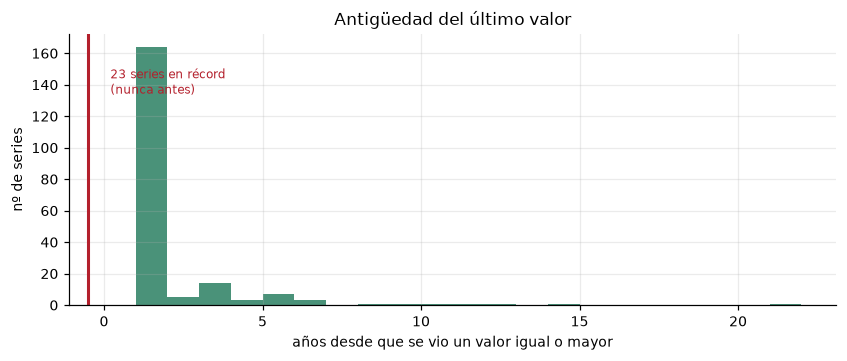

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.2))
d = ant.anios_sin_ver_igual_o_mayor.dropna()
ax.hist(d, bins=range(0, int(d.max()) + 2), color='#2a7f62', alpha=.85)
n_rec = int(ant.max_al_final.sum())
ax.axvline(-.5, color='#b3202c', lw=2)
ax.annotate(f'{n_rec} series en récord\n(nunca antes)',
            (0.2, ax.get_ylim()[1] * .78), color='#b3202c', fontsize=8)
ax.set(xlabel='años desde que se vio un valor igual o mayor',
       ylabel='nº de series', title='Antigüedad del último valor')
plt.show()

---
## 5. ¿Estable, subiendo o bajando? ¿Fue atípico el último punto?

`tau` de Mann-Kendall va de −1 a +1 y `p` es la probabilidad de ver ese patrón
por azar. `z_ultimo` mide cuánto se sale el último punto de la tendencia
ajustada **sin él**.

In [14]:
def clasificar(r):
    if pd.isna(r.p):
        return 'serie corta'
    if r.p >= 0.05:
        return 'estable / sin tendencia clara'
    return 'sube' if r.tau > 0 else 'baja'


trend = elegibles.copy()
trend['patron'] = trend.apply(clasificar, axis=1)

tab = trend.pivot_table(index='indicador', columns='patron',
                        values='unidad', aggfunc='size').fillna(0).astype(int)
tab.index = tab.index.map(NOMBRE)
print('Cuántos países muestran cada patrón (Mann-Kendall, p<0.05):')
print()
print(tab.to_string())

Cuántos países muestran cada patrón (Mann-Kendall, p<0.05):

patron                        baja  estable / sin tendencia clara  sube
indicador                                                              
Índice CALCI                     4                             12     6
Rendimiento agrícola             6                              3     6
Impuestos ambientales            0                              3     1
Gestión pesquera                 0                              1    21
Emisiones GEI por cápita         5                              8     4
Rendimiento ganadero             4                              6     4
Red meteorológica                0                             12     6
Generación de energía            1                              4    13
Anomalías en precipitaciones     0                             21     1
Nivel del mar (anomalía)         0                              9    12
Anomalía temp. superficie        0                             12    10
Ano

In [15]:
# --------------------------- unanimidad: el gancho más fuerte
una = trend.groupby('indicador').agg(
    n_paises=('unidad', 'size'),
    suben=('patron', lambda s: int((s == 'sube').sum())),
    bajan=('patron', lambda s: int((s == 'baja').sum())))
una['sin_tendencia'] = una.n_paises - una.suben - una.bajan
una['unanimidad_pct'] = una[['suben', 'bajan']].max(axis=1) / una.n_paises * 100
una['nombre'] = una.index.map(NOMBRE)
print('Ordenado por unanimidad: "todos los países del Pacífico" es una frase potente')
print()
print(una.sort_values('unanimidad_pct', ascending=False)
      [['nombre', 'n_paises', 'suben', 'bajan', 'sin_tendencia', 'unanimidad_pct']]
      .to_string())

Ordenado por unanimidad: "todos los países del Pacífico" es una frase potente

                                            nombre  n_paises  suben  bajan  sin_tendencia  unanimidad_pct
indicador                                                                                                
fisheries                         Gestión pesquera        22     21      0              1          95.455
power_gen                    Generación de energía        18     13      1              4          72.222
sea_level                 Nivel del mar (anomalía)        21     12      0              9          57.143
temp_anomaly                 Anomalía temp. marina        21     10      0             11          47.619
surface_temp_anomaly     Anomalía temp. superficie        22     10      0             12          45.455
crop_yield                    Rendimiento agrícola        15      6      6              3          40.000
met_network                      Red meteorológica        18      6      

In [16]:
# --------------------------- último punto atípico
atip = (trend.dropna(subset=['z_ultimo'])
        .assign(absz=lambda d: d.z_ultimo.abs()).nlargest(18, 'absz'))
atip['nombre'] = atip.indicador.map(NOMBRE)
print('Últimos puntos que más se salen de su propia tendencia:')
print()
print(atip[['unidad', 'nombre', 'n', 'hasta', 'ultimo', 'esperado', 'z_ultimo']]
      .to_string(index=False))
print()
print('CUIDADO: casi todo lo de turismo con z muy negativo es la serie')
print('CORTÁNDOSE en plena pandemia, no un dato raro. El punto es atípico')
print('respecto a la tendencia previa, pero la causa se conoce. Ver §8.')

Últimos puntos que más se salen de su propia tendencia:

unidad                nombre  n  hasta     ultimo    esperado  z_ultimo
    WS   Llegada de turistas 17   2022 50,600.000 160,100.000   -23.571
    VU   Llegada de turistas 19   2022 65,000.000 417,975.000   -14.192
    PG   Llegada de turistas 15   2022 69,400.000 220,000.000    -9.523
    NU Generación de energía 21   2023      4.500       3.529     9.173
    TO   Llegada de turistas 20   2022 22,300.000  82,925.000    -7.679
    FJ  Rendimiento ganadero 22   2024  4,317.000   7,683.360    -6.955
    TO      Gestión pesquera 24   2026     77.000      83.500    -5.846
    NC   Llegada de turistas 22   2024 59,399.000 558,750.000    -5.832
    VU  Rendimiento ganadero 22   2024  3,306.600   2,421.055     5.349
    CK  Rendimiento ganadero 22   2024    173.300     111.083     4.780
    FJ Impuestos ambientales 11   2020      0.400       1.342    -4.764
    NR Impuestos ambientales  9   2020      0.150       1.505    -4.717
    GU 

---
## 6. Ficha de una serie — el explorador

`ficha(pais, indicador)` dibuja cualquier serie con su tendencia, sus extremos
y su diagnóstico. Es la herramienta para verificar a mano cualquier afirmación
antes de meterla en la historia. `panel(indicador)` hace lo mismo para todos
los países a la vez.

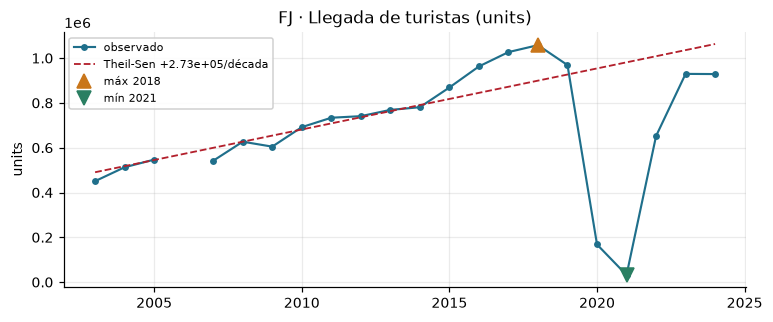

n=21  2003-2024  (3 años sin dato)
último 9.289e+05 en 2024   ·   mín 3.2e+04 (2021)   máx 1.058e+06 (2018)
tendencia: SUBE  (tau=+0.47, p=0.0034)
último punto: esperado 1.083e+06, observado 9.289e+05 -> z=-2.7 (algo fuera)
no se veía un valor igual o mayor desde hace 1 años


<Axes: title={'center': 'FJ · Llegada de turistas (units)'}, ylabel='units'>

In [17]:
def ficha(unidad, indicador, ax=None):
    g = df[(df.unidad == unidad) & (df.indicador == indicador)].sort_values('anio')
    obs = g.dropna(subset=['valor'])
    if len(obs) < 2:
        print(f'{unidad}/{indicador}: sin datos suficientes')
        return None
    a, v = obs.anio.values.astype(float), obs.valor.values

    propio = ax is None
    if propio:
        fig, ax = plt.subplots(figsize=(8, 3))

    # los huecos se dibujan como huecos: la línea se corta donde no hay dato
    ax.plot(g.anio, g.valor, '-o', ms=3.5, lw=1.4, color='#1f6f8b', label='observado')
    m, b = theil_sen(a, v)
    if not np.isnan(m):
        ax.plot(a, m * a + b, '--', lw=1.2, color='#b3202c',
                label=f'Theil-Sen {m * 10:+.3g}/década')
    imax, imin = int(np.argmax(v)), int(np.argmin(v))
    ax.plot(a[imax], v[imax], '^', color='#c9761a', ms=9, label=f'máx {a[imax]:.0f}')
    ax.plot(a[imin], v[imin], 'v', color='#2a7f62', ms=9, label=f'mín {a[imin]:.0f}')
    if indicador in DIVERGENTE:
        ax.axhline(0, color='#888', lw=.8, zorder=0)

    ax.set(title=f'{unidad} · {NOMBRE[indicador]} ({UNIDAD[indicador]})',
           ylabel=UNIDAD[indicador])
    ax.legend(fontsize=7, framealpha=.9)
    if not propio:
        return ax

    plt.show()
    tau, p = mann_kendall(v)
    esp, z = atipicidad_ultimo(a, v)
    print(f'n={len(obs)}  {int(a[0])}-{int(a[-1])}  '
          f'({len(g) - len(obs)} años sin dato)')
    print(f'último {v[-1]:,.4g} en {int(a[-1])}   ·   '
          f'mín {v[imin]:,.4g} ({a[imin]:.0f})   máx {v[imax]:,.4g} ({a[imax]:.0f})')
    if not np.isnan(p):
        veredicto = ('sin tendencia clara' if p >= .05
                     else ('SUBE' if tau > 0 else 'BAJA'))
        print(f'tendencia: {veredicto}  (tau={tau:+.2f}, p={p:.4f})')
    if not np.isnan(z):
        cal = 'normal' if abs(z) < 2 else ('algo fuera' if abs(z) < 3 else 'ATÍPICO')
        print(f'último punto: esperado {esp:,.4g}, observado {v[-1]:,.4g} '
              f'-> z={z:+.1f} ({cal})')
    r = resumen[(resumen.unidad == unidad) & (resumen.indicador == indicador)]
    if len(r):
        r = r.iloc[0]
        if r.max_al_final:
            print('es el MÁXIMO de toda la serie: nunca antes se vio algo así')
        elif pd.notna(r.anios_sin_ver_igual_o_mayor):
            print(f'no se veía un valor igual o mayor desde hace '
                  f'{int(r.anios_sin_ver_igual_o_mayor)} años')
    return ax


ficha('FJ', 'tourism')

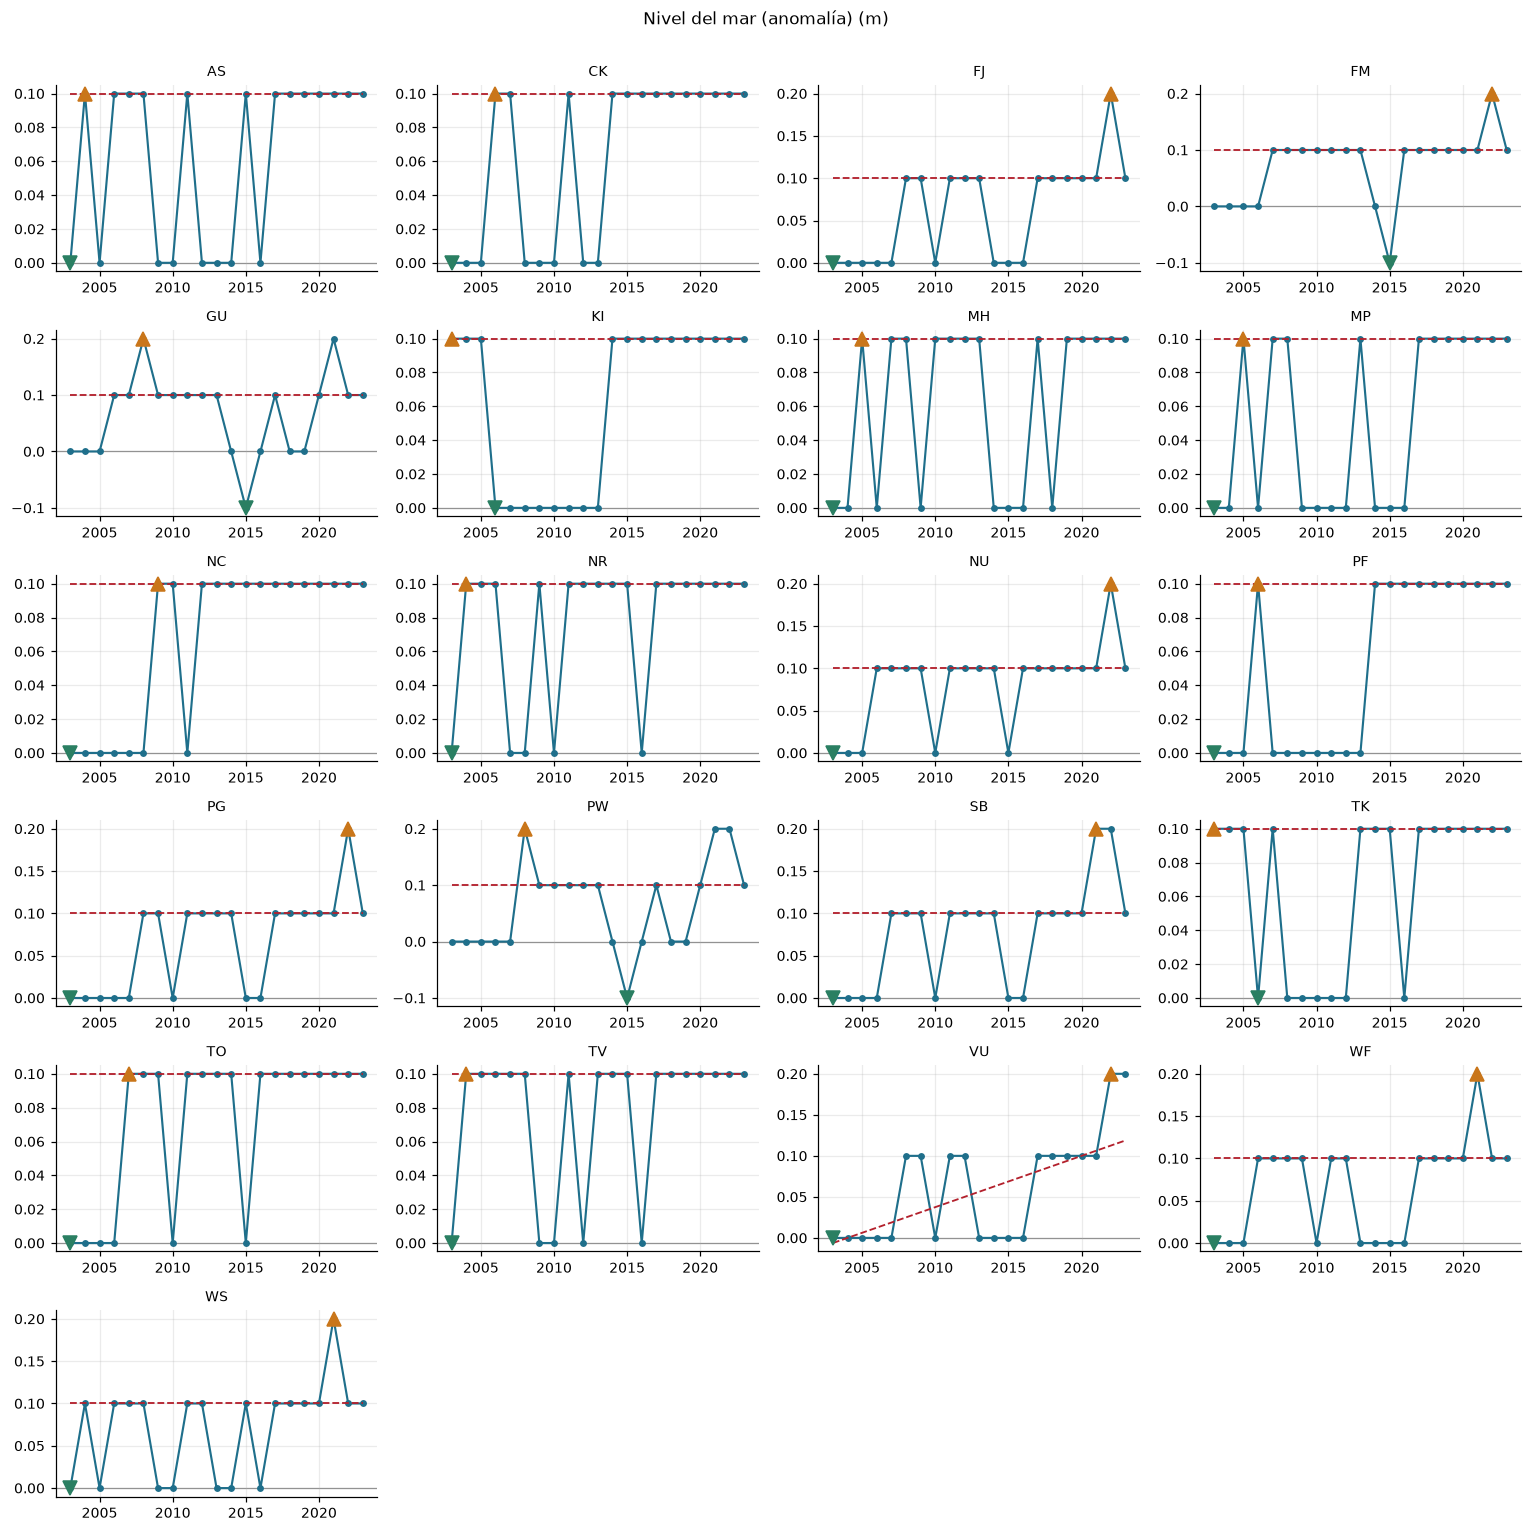

In [18]:
def panel(indicador, unidades=None, ncols=4):
    unidades = unidades or sorted(
        resumen[(resumen.indicador == indicador) & (resumen.n >= N_MIN)].unidad)
    n = len(unidades)
    if not n:
        print('sin series con datos suficientes')
        return
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 2.3 * nrows),
                             squeeze=False)
    for ax, u in zip(axes.flat, unidades):
        if ficha(u, indicador, ax=ax) is not None:
            ax.set_title(u, fontsize=9)
            ax.set_ylabel('')
            leg = ax.get_legend()
            if leg:
                leg.remove()
    for ax in axes.flat[n:]:
        ax.axis('off')
    fig.suptitle(f'{NOMBRE[indicador]} ({UNIDAD[indicador]})', y=1.005)
    fig.tight_layout()
    plt.show()


panel('sea_level')

---
## 7. Años sincronizados

Un país en récord es una anécdota; veinte países en récord el mismo año es un
acontecimiento.

**Solo se cuentan extremos interiores.** El primer y el último año de una serie
están estructuralmente inflados: en una serie que sube, el mínimo cae en el
primer año *por definición*, no porque pasara nada. Contándolos, 2003 aparecía
con 87 mínimos simultáneos —un artefacto puro, no un acontecimiento—. Un
extremo rodeado de años por ambos lados sí es un pico real.

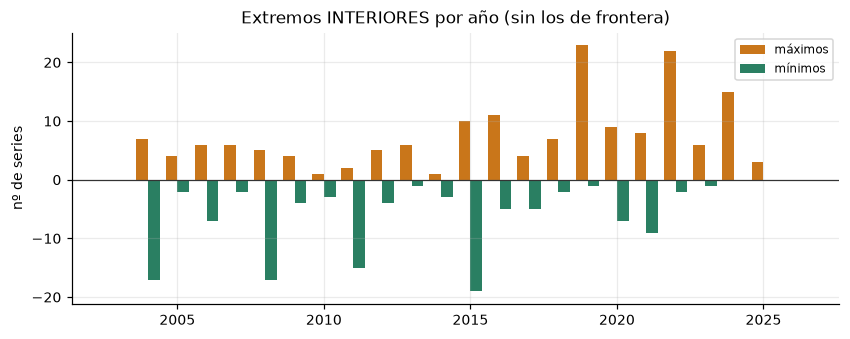

291 extremos interiores de 226 series elegibles
(los otros caen en el primer o el último año y no dicen nada)

      maximos  minimos
anio                  
2004        7       17
2005        4        2
2006        6        7
2007        6        2
2008        5       17
2009        4        4
2010        1        3
2011        2       15
2012        5        4
2013        6        1
2014        1        3
2015       10       19
2016       11        5
2017        4        5
2018        7        2
2019       23        1
2020        9        7
2021        8        9
2022       22        2
2023        6        1
2024       15        0
2025        3        0


In [19]:
sy = []
for (u, i), g in PAIS.groupby(['unidad', 'indicador']):
    g = g.sort_values('anio')
    v, a = g.valor.values, g.anio.values
    if len(v) < N_MIN:
        continue
    for etiqueta, idx in (('max', int(np.argmax(v))), ('min', int(np.argmin(v)))):
        if 0 < idx < len(v) - 1:                  # descarta extremos de frontera
            sy.append(dict(unidad=u, indicador=i, tipo=etiqueta, anio=int(a[idx])))
SY = pd.DataFrame(sy)

sinc = pd.DataFrame({
    'maximos': SY[SY.tipo == 'max'].groupby('anio').size(),
    'minimos': SY[SY.tipo == 'min'].groupby('anio').size()})
sinc = sinc.reindex(range(int(YEARS[0]), int(YEARS[-1]) + 1)).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(sinc.index - .2, sinc.maximos, .4, label='máximos', color='#c9761a')
ax.bar(sinc.index + .2, -sinc.minimos, .4, label='mínimos', color='#2a7f62')
ax.axhline(0, color='#333', lw=.8)
ax.set(title='Extremos INTERIORES por año (sin los de frontera)',
       ylabel='nº de series')
ax.legend(fontsize=8)
plt.show()

print(f'{len(SY)} extremos interiores de {len(elegibles)} series elegibles')
print(f'(los otros caen en el primer o el último año y no dicen nada)')
print()
print(sinc[(sinc.maximos + sinc.minimos) > 0].to_string())

In [20]:
top_max = int(sinc.maximos.idxmax())
top_min = int(sinc.minimos.idxmax())
for anio, tipo, cuantos in ((top_max, 'max', sinc.maximos.max()),
                            (top_min, 'min', sinc.minimos.max())):
    sel = SY[(SY.anio == anio) & (SY.tipo == tipo)]
    print(f'--- {anio}: {cuantos} {"máximos" if tipo == "max" else "mínimos"} '
          f'interiores simultáneos')
    print(sel.assign(nombre=sel.indicador.map(NOMBRE))
          .groupby('nombre').unidad.apply(lambda s: ' '.join(sorted(s))).to_string())
    print()

--- 2019: 23 máximos interiores simultáneos
nombre
Anomalía temp. marina                                   CK WF
Anomalía temp. superficie                                  WF
Anomalías en precipitaciones    AS CK FM NR NU PF PG TO TV WF
Generación de energía                                      VU
Gestión pesquera                                        MP TK
Impuestos ambientales                                      PG
Llegada de turistas                               PF PG TO WS
Rendimiento agrícola                                       FJ
Rendimiento ganadero                                       TV

--- 2015: 19 mínimos interiores simultáneos
nombre
Anomalía temp. marina           FJ NU PG SB TO VU
Anomalía temp. superficie          FJ NU SB TO VU
Anomalías en precipitaciones       FJ PG PW TO WF
Nivel del mar (anomalía)                 FM GU PW



---
## 8. Choque y recuperación

Para cada serie se busca la mayor caída desde un máximo previo y se mide si
volvió a ese nivel y cuánto tardó. **Solo indicadores de nivel**: un porcentaje
sobre una anomalía no significa nada (regla 2).

In [21]:
choques = []
for (u, i), g in PAIS.groupby(['unidad', 'indicador']):
    if i in DIVERGENTE:
        continue
    g = g.sort_values('anio')
    v, a = g.valor.values, g.anio.values
    if len(v) < N_MIN or v.min() <= 0:
        continue
    pico = np.maximum.accumulate(v)
    caida = (v - pico) / pico
    k = int(np.argmin(caida))
    if caida[k] > -.30:                       # solo desplomes de más del 30 %
        continue
    nivel = pico[k]
    vuelta = np.where(v[k:] >= nivel)[0]
    choques.append(dict(
        unidad=u, indicador=i, anio_fondo=int(a[k]), caida_pct=caida[k] * 100,
        nivel_previo=nivel, fondo=v[k], recuperado=bool(len(vuelta)),
        anios_en_recuperar=int(a[k + vuelta[0]] - a[k]) if len(vuelta) else np.nan,
        pct_del_pico_al_final=v[-1] / nivel * 100, ultimo_anio=int(a[-1])))

CH = pd.DataFrame(choques).sort_values('caida_pct')
CH['nombre'] = CH.indicador.map(NOMBRE)
print(f'{len(CH)} desplomes de más del 30 %')
print()
print(CH.head(14)[['unidad', 'nombre', 'anio_fondo', 'caida_pct', 'recuperado',
                   'pct_del_pico_al_final', 'ultimo_anio']].to_string(index=False))

38 desplomes de más del 30 %

unidad                   nombre  anio_fondo  caida_pct  recuperado  pct_del_pico_al_final  ultimo_anio
    TO      Llegada de turistas        2021    -99.787       False                 23.723         2022
    WS      Llegada de turistas        2021    -98.564       False                 27.956         2022
    MP      Llegada de turistas        2021    -98.076       False                 14.636         2022
    NC      Llegada de turistas        2021    -97.792       False                  9.489         2024
    FJ      Llegada de turistas        2021    -96.975       False                 87.801         2024
    KI      Llegada de turistas        2017    -94.235       False                  9.224         2019
    NR    Impuestos ambientales        2020    -93.478       False                  6.522         2020
    PG      Llegada de turistas        2021    -91.943       False                 32.891         2022
    VU      Llegada de turistas        2022

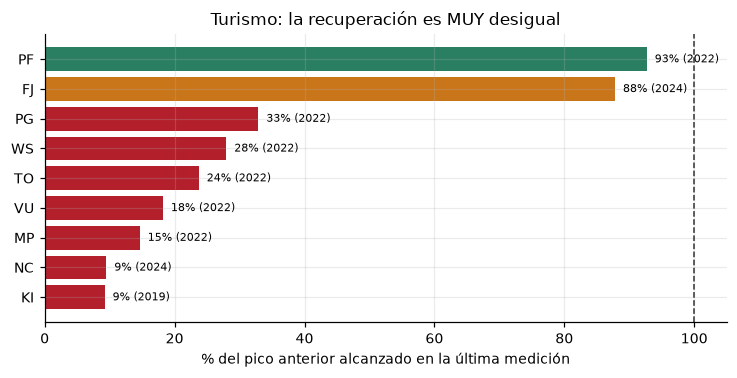

Ninguna serie de turismo ha vuelto a su pico. La distancia entre Fiyi y
Nueva Caledonia es el gancho: el mismo choque, destinos opuestos.
Aviso: varias series se cortan en 2022, todavía dentro del hoyo.


In [22]:
tur = CH[CH.indicador == 'tourism'].sort_values('pct_del_pico_al_final')
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(tur.unidad, tur.pct_del_pico_al_final,
        color=['#b3202c' if x < 50 else '#c9761a' if x < 90 else '#2a7f62'
               for x in tur.pct_del_pico_al_final])
ax.axvline(100, color='#333', lw=1, ls='--')
ax.set(xlabel='% del pico anterior alcanzado en la última medición',
       title='Turismo: la recuperación es MUY desigual')
for _, r in tur.iterrows():
    ax.annotate(f'  {r.pct_del_pico_al_final:.0f}% ({r.ultimo_anio})',
                (r.pct_del_pico_al_final, r.unidad), va='center', fontsize=7)
plt.show()
print('Ninguna serie de turismo ha vuelto a su pico. La distancia entre Fiyi y')
print('Nueva Caledonia es el gancho: el mismo choque, destinos opuestos.')
print('Aviso: varias series se cortan en 2022, todavía dentro del hoyo.')

---
## 9. ¿Se abre o se cierra la brecha entre países?

Dispersión entre países, año a año. Para indicadores de nivel se usa el **IQR
relativo** (comparable entre magnitudes distintas); para anomalías, el **IQR
absoluto**, porque dividir por una mediana que ronda el cero explota.

In [23]:
disp_series, filas = {}, []
for i, g in PAIS.groupby('indicador'):
    w = g.pivot_table(index='anio', columns='unidad', values='valor')
    w = w[w.notna().sum(axis=1) >= 5]
    if len(w) < N_MIN:
        continue
    iqr = w.quantile(.75, axis=1) - w.quantile(.25, axis=1)
    d = iqr if i in DIVERGENTE else iqr / w.median(axis=1).abs()
    d = d.replace([np.inf, -np.inf], np.nan).dropna()
    if len(d) < N_MIN:
        continue
    disp_series[i] = d
    ini, fin_ = d.iloc[:3].mean(), d.iloc[-3:].mean()
    m, _ = theil_sen(d.index.values, d.values)
    filas.append(dict(indicador=i, nombre=NOMBRE[i],
                      tipo='anomalía' if i in DIVERGENTE else 'nivel',
                      inicio=ini, final=fin_,
                      cambio_pct=(fin_ / ini - 1) * 100 if ini > 0 else np.nan,
                      pend_decada=m * 10))
DP = pd.DataFrame(filas).sort_values('cambio_pct')
print('Negativo = los países CONVERGEN · positivo = la brecha se ABRE')
print()
print(DP[['nombre', 'tipo', 'inicio', 'final', 'cambio_pct']].to_string(index=False))

Negativo = los países CONVERGEN · positivo = la brecha se ABRE

                      nombre     tipo  inicio  final  cambio_pct
                Índice CALCI    nivel   0.057  0.018     -69.235
    Nivel del mar (anomalía) anomalía   0.067  0.033     -50.000
        Rendimiento agrícola    nivel   0.602  0.439     -27.093
         Llegada de turistas    nivel   2.226  1.657     -25.545
       Anomalía temp. marina anomalía   0.267  0.200     -25.000
       Generación de energía    nivel   6.817  5.742     -15.767
           Red meteorológica    nivel   1.000  0.917      -8.333
   Anomalía temp. superficie anomalía   0.292  0.283      -2.857
Anomalías en precipitaciones anomalía  12.850 13.092       1.881
    Emisiones GEI por cápita    nivel   2.400  3.046      26.929
            Gestión pesquera    nivel   0.545  0.809      48.541
        Rendimiento ganadero    nivel   1.246  1.935      55.274


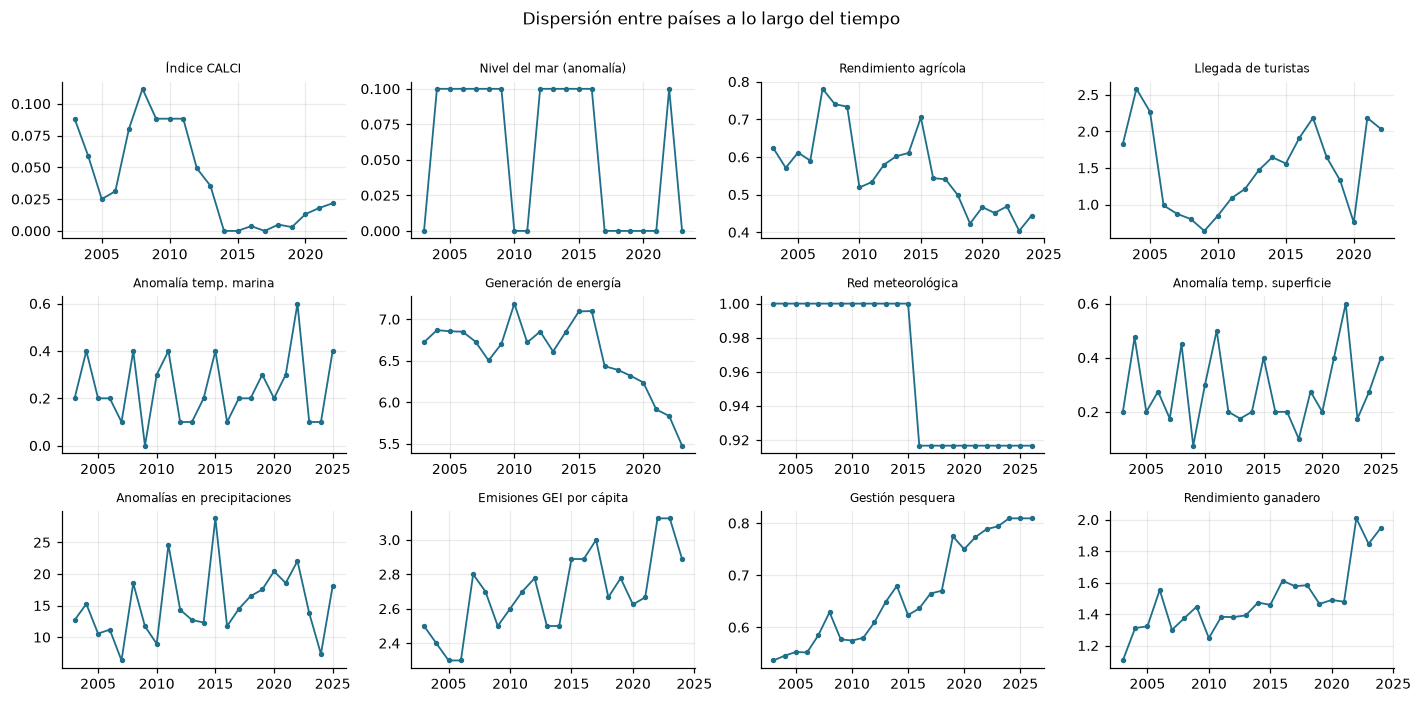

Mirar la FORMA, no solo la pendiente: una serie que sube y baja puede
dar una pendiente engañosa aunque empiece y acabe igual.


In [24]:
ordenados = DP.dropna(subset=['cambio_pct']).indicador.tolist()
n = len(ordenados)
nrows = math.ceil(n / 4)
fig, axes = plt.subplots(nrows, 4, figsize=(13, 2.1 * nrows), squeeze=False)
for ax, i in zip(axes.flat, ordenados):
    d = disp_series[i]
    ax.plot(d.index, d.values, '-o', ms=2.5, lw=1.2, color='#1f6f8b')
    ax.set_title(NOMBRE[i], fontsize=8)
for ax in axes.flat[n:]:
    ax.axis('off')
fig.suptitle('Dispersión entre países a lo largo del tiempo', y=1.005)
fig.tight_layout()
plt.show()
print('Mirar la FORMA, no solo la pendiente: una serie que sube y baja puede')
print('dar una pendiente engañosa aunque empiece y acabe igual.')

---
## 10. Qué indicadores se mueven juntos

Correlación de Spearman (por rangos, no supone relación lineal) **dentro de
cada país**, y después la mediana entre países. Calcularla sobre todos los
países mezclados mediría diferencias de tamaño entre países, no co-movimiento
en el tiempo.

In [25]:
piv = {u: g.pivot_table(index='anio', columns='indicador', values='valor')
       for u, g in PAIS.groupby('unidad')}
pares = []
for a, b in itertools.combinations(sorted(PAIS.indicador.unique()), 2):
    rs = []
    for w in piv.values():
        if a not in w or b not in w:
            continue
        par = w[[a, b]].dropna()
        if len(par) < N_MIN:
            continue
        # una serie constante no tiene rangos que correlacionar: su correlación
        # es indefinida, no cero. Incluirla contaminaría la mediana con NaN
        # (y numpy lo grita con avisos de división por cero).
        if par[a].nunique() < 3 or par[b].nunique() < 3:
            continue
        r = par[a].rank().corr(par[b].rank())     # Pearson sobre rangos = Spearman
        if pd.notna(r):
            rs.append(r)
    if len(rs) >= 8:
        med = float(np.median(rs))
        pares.append(dict(indicador_a=NOMBRE[a], indicador_b=NOMBRE[b], rho=med,
                          n_paises=len(rs),
                          mismo_signo_pct=float(np.mean(np.sign(rs) == np.sign(med)) * 100)))
CO = pd.DataFrame(pares)
CO = CO.reindex(CO.rho.abs().sort_values(ascending=False).index)
print('rho = mediana entre países · mismo_signo_pct = consistencia entre países')
print()
print(CO.head(15).to_string(index=False))
print()
print('La primera pareja (anomalía de temperatura marina y de superficie,')
print('rho~0.98) no es un hallazgo: son dos medidas de lo mismo. Sirve de')
print('control — si el método no la detectara, estaría roto.')

rho = mediana entre países · mismo_signo_pct = consistencia entre países

                 indicador_a               indicador_b    rho  n_paises  mismo_signo_pct
   Anomalía temp. superficie     Anomalía temp. marina  0.984        21          100.000
            Gestión pesquera     Generación de energía  0.805        18           83.333
        Rendimiento agrícola      Rendimiento ganadero  0.643        14           78.571
            Gestión pesquera  Nivel del mar (anomalía)  0.569         9           88.889
            Gestión pesquera Anomalía temp. superficie  0.501        20          100.000
            Gestión pesquera  Emisiones GEI por cápita -0.476        10           60.000
            Gestión pesquera     Anomalía temp. marina  0.473        20          100.000
                Índice CALCI      Rendimiento agrícola  0.444        11           81.818
       Generación de energía  Nivel del mar (anomalía)  0.436         9           88.889
    Nivel del mar (anomalía) Anomalí

---
## 11. Qué país se sale del grupo

In [26]:
zs = []
for i, g in PAIS.groupby('indicador'):
    ult = g.sort_values('anio').groupby('unidad').tail(1)
    if len(ult) < 6:
        continue
    med = ult.valor.median()
    mad = (ult.valor - med).abs().median()
    if mad <= 0:
        continue
    for _, r in ult.iterrows():
        zs.append(dict(unidad=r.unidad, nombre=NOMBRE[i], anio=int(r.anio),
                       valor=r.valor, mediana_grupo=med,
                       z=(r.valor - med) / (1.4826 * mad)))
ZS = pd.DataFrame(zs)
print('Último valor de cada país frente a la mediana del grupo (z robusto):')
print()
print(ZS.reindex(ZS.z.abs().sort_values(ascending=False).index).head(15)
      .to_string(index=False))
print()
print('Los z enormes de generación eléctrica y GEI son sobre todo TAMAÑO (PNG y')
print('Nueva Caledonia son mucho mayores), no anomalía de comportamiento. Para')
print('una historia son más interesantes los z medianos en índices o per cápita.')

Último valor de cada país frente a la mediana del grupo (z robusto):

unidad                       nombre  anio       valor  mediana_grupo      z
    PW     Emisiones GEI por cápita  2024      86.700          0.900 72.339
    NC        Generación de energía  2023   3,348.500         86.750 34.619
    PG        Generación de energía  2023   2,841.700         86.750 29.240
    GU        Generación de energía  2023   1,629.800         86.750 16.377
    FJ          Llegada de turistas  2024 928,938.000     59,399.000 15.766
    NC     Emisiones GEI por cápita  2024      18.400          0.900 14.754
    FJ        Generación de energía  2023   1,284.500         86.750 12.712
    GU          Llegada de turistas  2024 739,146.000     59,399.000 12.324
    FJ         Rendimiento agrícola  2024  26,793.800      5,830.300  8.871
    PF        Generación de energía  2023     629.300         86.750  5.758
    PF          Llegada de turistas  2022 261,400.000     59,399.000  3.662
    NR Anomalías e

---
## 12. Ganchos narrativos, ordenados por fuerza

In [27]:
# `fuerza` NO es comparable entre categorías: un 95 % de unanimidad y una caída
# del 95 % son números que se parecen y no miden lo mismo. Por eso cada gancho
# lleva su `medida` al lado y la lista se agrupa por categoría en vez de
# presentar un único ranking que invitaría a comparar peras con manzanas.
ganchos = []
add = lambda cat, f, med, txt: ganchos.append(
    dict(categoria=cat, fuerza=f, medida=med, gancho=txt))

for i, r in una.iterrows():                       # unanimidad de tendencia
    dom, dirn = ((r.suben, 'suben') if r.suben >= r.bajan else (r.bajan, 'bajan'))
    if r.n_paises >= 8 and dom / r.n_paises >= .5:
        add('UNANIMIDAD', 100 * dom / r.n_paises, '% de países en la misma dirección',
            f'{NOMBRE[i]}: {dom} de {r.n_paises} países {dirn}; '
            f'{r.bajan if dirn == "suben" else r.suben} van al revés')

for i, r in por_ind.iterrows():                   # récords simultáneos
    if r.en_maximo >= 4:
        add('RÉCORD', 100 * r.en_maximo / r.de_un_total_de, '% de países en máximo',
            f'{NOMBRE[i]}: {r.en_maximo} de {r.de_un_total_de} países en su '
            f'máximo histórico ({r.anio})')

# Un gancho POR INDICADOR, no uno por país: nueve filas diciendo "el turismo se
# desplomó" son la misma noticia nueve veces y desplazaban a todo lo demás.
# Lo que sí es noticia es el reparto: quién volvió y quién no.
for i, g in CH[CH.caida_pct < -60].groupby('indicador'):
    if len(g) < 2:
        continue
    peor = g.nsmallest(1, 'caida_pct').iloc[0]
    lento = g.nsmallest(1, 'pct_del_pico_al_final').iloc[0]
    rapido = g.nlargest(1, 'pct_del_pico_al_final').iloc[0]
    add('CHOQUE', abs(peor.caida_pct), '% de la peor caída',
        f'{NOMBRE[i]}: {len(g)} países cayeron más del 60 % (peor {peor.unidad}, '
        f'{peor.caida_pct:.0f}% en {peor.anio_fondo}). Hoy van del '
        f'{lento.pct_del_pico_al_final:.0f}% ({lento.unidad}) al '
        f'{rapido.pct_del_pico_al_final:.0f}% ({rapido.unidad}) del pico')

for _, r in DP.dropna(subset=['cambio_pct']).iterrows():
    if abs(r.cambio_pct) > 40:
        add('BRECHA', abs(r.cambio_pct), '% de cambio en la dispersión',
            f'{r.nombre}: la distancia entre países '
            f'{"se ABRE" if r.cambio_pct > 0 else "se CIERRA"} '
            f'un {abs(r.cambio_pct):.0f}%')

# sincronía: se mide contra el azar, no en bruto. Si los extremos se repartieran
# por igual entre los años, tocarían ~n/años por año; lo interesante es el
# múltiplo sobre esa expectativa.
anios_activos = int((sinc.sum(axis=1) > 0).sum())
for col, etiqueta in (('minimos', 'mínimo'), ('maximos', 'máximo')):
    total = int(sinc[col].sum())
    if not total or not anios_activos:
        continue
    esperado = total / anios_activos
    anio, cuantos = int(sinc[col].idxmax()), int(sinc[col].max())
    if cuantos >= 3 * esperado:
        detalle = SY[(SY.anio == anio) & (SY.tipo == col[:3])]
        inds = detalle.indicador.map(NOMBRE).value_counts()
        add('SINCRONÍA', cuantos / esperado, 'veces por encima de lo esperado',
            f'{anio}: {cuantos} series tocaron su {etiqueta} interior el mismo año '
            f'({cuantos / esperado:.1f}× lo esperado). Sobre todo '
            f'{", ".join(f"{k} ({v})" for k, v in inds.head(3).items())}')

G = (pd.DataFrame(ganchos)
     .sort_values(['categoria', 'fuerza'], ascending=[True, False])
     .reset_index(drop=True))
pd.set_option('display.max_colwidth', 150)
for cat, g in G.groupby('categoria', sort=True):
    print(f'### {cat}   ({g.medida.iloc[0]})')
    for _, r in g.iterrows():
        print(f'   {r.fuerza:6.1f}  {r.gancho}')
    print()

### BRECHA   (% de cambio en la dispersión)
     69.2  Índice CALCI: la distancia entre países se CIERRA un 69%
     55.3  Rendimiento ganadero: la distancia entre países se ABRE un 55%
     50.0  Nivel del mar (anomalía): la distancia entre países se CIERRA un 50%
     48.5  Gestión pesquera: la distancia entre países se ABRE un 49%

### CHOQUE   (% de la peor caída)
     99.8  Llegada de turistas: 9 países cayeron más del 60 % (peor TO, -100% en 2021). Hoy van del 9% (KI) al 93% (PF) del pico
     93.5  Impuestos ambientales: 2 países cayeron más del 60 % (peor NR, -93% en 2020). Hoy van del 7% (NR) al 25% (PG) del pico

### RÉCORD   (% de países en máximo)
     50.0  Generación de energía: 9 de 18 países en su máximo histórico (2023)
     27.3  Anomalía temp. superficie: 6 de 22 países en su máximo histórico (2025)
     23.8  Anomalía temp. marina: 5 de 21 países en su máximo histórico (2025)

### SINCRONÍA   (veces por encima de lo esperado)
      3.3  2015: 19 series tocaron su mí

---
## 13. Qué contaría yo

Tres historias que aguantan el escrutinio, en orden de solidez. Los números
salen de las celdas anteriores; conviene volver a mirarlos si los datos cambian.

**1. Nadie mejora: el mar solo sube.**
La afirmación precisa no es «todos los países suben», sino algo más raro y más
fuerte: **ninguno baja**. En nivel del mar, 12 de 21 países tienen subida
significativa y **0 tienen bajada**; en anomalía de temperatura marina, 10 de
21 y 0; en temperatura de superficie, 10 de 22 y 0. Los demás salen «sin
tendencia clara», que no es lo mismo que estable a la baja. Un indicador
climático donde *nadie* mejora en veinte años no necesita adornos.
*Aviso obligatorio:* el nivel del mar viene redondeado a 0.1 m sobre un rango
total de 0.3 m — cuatro valores posibles (§1). La dirección es sólida; la
magnitud no se puede contar en detalle, ni comparar países entre sí.

**2. El turismo: el mismo golpe, recuperaciones opuestas.**
Todos se desplomaron entre 2020 y 2021 —hasta un −99.8 % en Tonga—, pero la
última medición encuentra a Fiyi cerca del 88 % de su pico y a Nueva Caledonia
por debajo del 10 %. Un choque común con destinos divergentes es mejor relato
que un choque a secas. *Aviso:* varias series se cortan en 2022, todavía dentro
del hoyo; hay que decir el año de cada una o se exagera la caída.

**3. Lo que el tablero no puede mostrar.**
La cobertura cae del ~79 % al 14 % en los últimos cuatro años; hay 58 series
planas o casi planas (Samoa Americana: 0.2 t de GEI durante 22 años seguidos;
Kiribati: CALCI clavado en 100) y magnitudes imposibles (Palau, ~87 t de GEI
por cápita, por encima de Qatar). Un tablero que dibujara los estratos vacíos
como ceros mentiría; por eso los estratos sin dato se dejan **invisibles, con
el hueco a la vista**. El hueco es parte de la historia.

### Dos candidatos que NO usaría, y por qué

- **«Gestión pesquera mejora en 21 de 22 países» (95 % de unanimidad).** Es el
  número más llamativo del cuaderno y por eso desconfío: la serie es un conteo
  entero que crece casi monótonamente en todas partes, lo que huele a un
  indicador acumulativo (medidas adoptadas, no revocables) más que a una
  medición del estado del mar. Una tendencia al alza en algo que solo puede
  subir no es un hallazgo. Verificar la definición en la fuente antes de
  contarlo.
- **«Récord en generación eléctrica en 9 países».** Los nueve son de 2023 y
  la serie entera acaba en 2023: es el último dato disponible, y en una serie
  que crece, el último dato es el máximo casi siempre. Sin años posteriores no
  hay forma de distinguir «récord» de «final del registro».

### Análisis que aún no están y podrían aportar

- **Retardo entre indicadores.** ¿La anomalía de temperatura precede a la caída
  del rendimiento agrícola en 1–2 años? Con 22 puntos es frágil, pero la
  correlación cruzada por retardos lo puede explorar.
- **Vínculo con ENSO.** Superponer los años de El Niño / La Niña sobre la
  sincronía de §7 explicaría de golpe los años de mínimos simultáneos.
- **Cambio de ritmo.** Comparar la pendiente 2003–2013 con la de 2014–2024 dice
  si la subida se *acelera*, no solo si existe. Es un titular distinto.
- **Normalizar por área de ZEE.** Pesca y emisiones por superficie marina
  aprovecharían la geometría que el tablero ya tiene cargada.
- **Rotación de posiciones.** Qué países han subido o bajado más puestos en el
  ranking de cada indicador: convierte una tabla estática en un movimiento.

In [28]:
# ------------------------------------------- exportar para el panel de historia
SAL = RAIZ / 'analysis' / 'salida'
SAL.mkdir(parents=True, exist_ok=True)
resumen.to_csv(SAL / 'resumen_series.csv', index=False, encoding='utf-8')
G.to_csv(SAL / 'ganchos.csv', index=False, encoding='utf-8')
CH.to_csv(SAL / 'choques.csv', index=False, encoding='utf-8')
una.to_csv(SAL / 'unanimidad.csv', encoding='utf-8')
DP.to_csv(SAL / 'dispersion.csv', index=False, encoding='utf-8')
print('escrito en', SAL)
for f in sorted(SAL.glob('*.csv')):
    print(f'  {f.name:24} {f.stat().st_size:>8,} bytes')

escrito en C:\Users\amado.esquer\Documents\Pacific Viz\Pacific-Viz-2026\analysis\salida
  choques.csv                 3,980 bytes
  dispersion.csv              1,401 bytes
  ganchos.csv                 2,076 bytes
  resumen_series.csv         44,364 bytes
  unanimidad.csv                853 bytes
